In [1]:
using SciMLSensitivity
using DifferentialEquations
using SciMLSensitivity   # or DiffEqSensitivity if you prefer
using Zygote
using Optimisers         # for optimizer & update
using LinearAlgebra
using DifferentialEquations
using Flux
using Plots
using Optimization
using OptimizationOptimisers
using Zygote
using DataFrames
using  JLD2
using Random
Random.seed!(1234)
println("All the nessecessary packages have been imported")

All the nessecessary packages have been imported


In [2]:
# Physics Constants (Explicit Float32)
const C_m  = 1.0f0      # µF/cm²
const g_Na = 120.0f0    # mS/cm²
const E_Na = 50.0f0     # mV
const g_L  = 0.3f0      # mS/cm²
const E_L  = -54.387f0  # mV

-54.387f0

In [3]:
# Voltage-gated ion channel kinetics (Float32)

α_n(V::Float32) = 0.01f0 * (V + 55f0) / (1f0 - exp(-(V + 55f0) / 10f0))
β_n(V::Float32) = 0.125f0 * exp(-(V + 65f0) / 80f0)

α_m(V::Float32) = 0.1f0 * (V + 40f0) / (1f0 - exp(-(V + 40f0) / 10f0))
β_m(V::Float32) = 4.0f0 * exp(-(V + 65f0) / 18f0)

α_h(V::Float32) = 0.07f0 * exp(-(V + 65f0) / 20f0)
β_h(V::Float32) = 1f0 / (1f0 + exp(-(V + 35f0) / 10f0))

# Steady-state & time-constant functions (Float32)

m_inf(V::Float32) = α_m(V) / (α_m(V) + β_m(V))
h_inf(V::Float32) = α_h(V) / (α_h(V) + β_h(V))
n_inf(V::Float32) = α_n(V) / (α_n(V) + β_n(V))

tau_n(V::Float32) = 1f0 / (α_n(V) + β_n(V))

println("Physics of neural dynamics defined in Float32")


Physics of neural dynamics defined in Float32


In [4]:
function Stimulus(t)
    # A 1ms pulse starting at 10ms
    return(t>=10.0 && t<11.0) ? 20 : 0.0
end

println(" An extra current form neighbour to generate a pulse")

 An extra current form neighbour to generate a pulse


In [5]:

# 2D Hodgkin-Huxley reduced model engine
function hodgkin_huxley_reduced!(du, u, p, t)
    V, n = u
    I_ext = Stimulus(t)


    # Known 2D current
    I_Na = g_Na * m_inf(V)^3 * h_inf(V) * (V - E_Na)
    I_K  = g_K  * n^4 * (V - E_K)
    I_L  = g_L * (V - E_L)
    du[1] = (  I_ext - (I_Na + I_K + I_L)   ) / Cm
    du[2] = (n_inf(V) - n) / tau_n(V)
end

# Generate Data
u0_true = [-65.0, n_inf(-65.0)]
tspan = (0.0, 50.0)
prob_true = ODEProblem(hodgkin_huxley_reduced!, u0_true, tspan)
sol_true = solve(prob_true, Rodas5P(), saveat=0.1,reltol=1e-10, abstol=1e-10)

# Extract and structure the training data
data_V = sol_true[1, :]
t_train = sol_true.t
data_n =sol_true[2, :]

# (Optional) Verify data shape and content
df = DataFrame(t=t_train, V=data_V , n = data_n)
println("Generated Training Data:")
display(first(df, 5))


MethodError: MethodError: no method matching n_inf(::Float64)
The function `n_inf` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  n_inf(!Matched::Float32)
   @ Main c:\Users\nirbh\Neural_Spiking_Dynamics\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:16


In [6]:
theme(:dark)
Membraneplot=plot(df.t,df.V,
 label="Action Potentail",
  color = :yellow, 
  linewidth =2,
  title = " Membrane Voltage",
  xlabel = "Time (ms)",
  ylabel = "Voltage ")



UndefVarError: UndefVarError: `df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing Rmath in the current active module Main

In [7]:
U = Chain(Dense(1,16,tanh),
Dense(16, 16) ,
Dense(16, 1)  ) |> Flux.f64 # Explicitly convert network to Float64




Chain(
  Dense(1 => 16, tanh),                 # 32 parameters
  Dense(16 => 16),                      # 272 parameters
  Dense(16 => 1),                       # 17 parameters
)                   # Total: 6 arrays, 321 parameters, 2.812 KiB.

In [8]:
# Extract the trainable parameters (p_nn) and the re-structuring function (re)
p_nn, re = Flux.destructure(U)
# Ensure parameters are Float64 for the ODE solver
p_nn = Float64.(p_nn)
println("Recruit Constructed. Parameters: ", length(p_nn))
println("Parameter element type: ", eltype(p_nn))






Recruit Constructed. Parameters: 321
Parameter element type: Float64


## The hybrid UDE

In [9]:
using  Statistics
# 6. CALCULATE NORMALIZATION STATS (Global Constants)
const V_mean = mean(data_V)
const V_std  = std(data_V)


norm_input(v)= (v-V_mean)/V_std
# 4. HYBRID DYNAMICS
function HH_2D_Ude_model!(du, u, p, t)
    V, n = u
    
    # Reconstruct NN from p
    nn_model = re(p)
    
    # Predict Sodium Current (Using Normalized Voltage)
    pred_I_Na = nn_model([norm_input(V)])[1]
    
    # Physics Terms
    I_ext = Stimulus(t)
    I_K   = g_K * n^4 * (V - E_K)
    I_L   = g_L * (V - E_L)
    
    # Dynamics
    du[1] = (I_ext - pred_I_Na - I_K - I_L) / Cm
    du[2] = (n_inf(V) - n) / tau_n(V)
end
prob_nn = ODEProblem(HH_2D_Ude_model!, u0_true, tspan, p_nn)



UndefVarError: UndefVarError: `data_V` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [10]:
# ---- ODE Problem Definition ----


# --- Start of Rectified Command Block ---

# --- 1. CONFIGURATION ---
const CHECKPOINT_FILE = "neuron_mission_log.jld2"
const BEST_FILE = "neuron_best_model.jld2"
# ...existing code...
const REGULARIZATION_STRENGTH = 0.0  # Protocol Zero: no weight penalty

function predict_ude(p)
    p_safe = Float64.(p)
    _prob = remake(prob_nn, p=p_safe)
    solve(_prob, Rodas5P(), saveat=t_train,
          reltol=1e-12, abstol=1e-12,
          sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()))
end

function loss(p)
    pred = predict_ude(p)
    if pred.retcode != :Success
        return 1e6
    end
    pred_V = pred[1, :]
    phys_loss = sum(abs2, pred_V .- data_V)
    reg_loss = REGULARIZATION_STRENGTH * sum(abs2, p)
    return phys_loss + reg_loss
end

# define optf after loss
optf = Optimization.OptimizationFunction((x, p) -> loss(x), Optimization.AutoZygote())
println("Optimization Function (optf) Defined (Protocol Zero).")

function extreme_polish(; maxiters=5000)
    println("🔥 PROTOCOL ZERO INITIATED: High-precision L-BFGS")
    start_params = isfile(BEST_FILE) ? Float64.(load(BEST_FILE)["params"]) : Float64.(p_nn)
    optprob_extreme = Optimization.OptimizationProblem(optf, start_params)
    res = Optimization.solve(optprob_extreme, OptimizationOptimJL.LBFGS(); maxiters=maxiters)
    println("EXTREME POLISH COMPLETE. Final Loss: $(res.objective)")
    if res.objective < best_loss_global
        jldsave("neuron_extreme_model.jld2"; params=Float64.(res.u), loss=res.objective)
        println("🏆 New Extreme Record saved.")
    else
        println("No improvement over previous best.")
    end
    return res
end
function create_callback(phase_name)
    return function (state, l) 
        # Note: In Optimization.jl, 'state' holds the current params in 'state.u'
        
        # A. Check for Explosions
        if isnan(l)
            @warn "!!! ABORT MISSION: Loss is NaN in $phase_name !!!"
            return true # Halts training
        end
        
        # B. Record History
        push!(all_losses, l)
        
        # C. CHECK FOR HEROIC PERFORMANCE (Save Best)
        global best_loss_global
        if l < best_loss_global
            best_loss_global = l
            # Save the Hero model separately
            jldsave(BEST_FILE; params=Float64.(state.u), loss=l)
            
            # Print update in-place (\r)
            print("🏆 New Best in $(phase_name)! Loss: $(round(l, digits=5))   \r")
            flush(stdout)
        end
        
        # D. REGULAR CHECKPOINT (Save Latest)
        # We always save this so we can resume if the PC crashes,
        # even if it wasn't a "best" score.
        jldsave(CHECKPOINT_FILE; params=Float64.(state.u), loss_history=all_losses)

        # E. Status Report (Every 50 steps)
        current_iter = length(all_losses)
        if current_iter % 10 == 0 # Changed from 50 to 10 for more frequent reports
            # Print a newline so we don't overwrite the "New Best" message
            println("\n[$phase_name] Iter: $current_iter | Loss: $l")
        end
        
        return false # Continue training
    end
end
# --- 6. RESUME FUNCTION ---
function load_checkpoint_if_exists(initial_params)
    if isfile(CHECKPOINT_FILE)
        println("📂 INTEL FOUND: Loading previous checkpoint...")
        try
            data = load(CHECKPOINT_FILE)
            # Restore global history
            global all_losses = data["loss_history"]
            
            # If we are resuming, update our best_loss tracker too
            global best_loss_global = minimum(all_losses)
            
            # Return saved parameters
            println("   -> Resuming from Iteration $(length(all_losses))")
            println("   -> Current Best Record: $best_loss_global")
            return Float64.(data["params"])
        catch e
            println("⚠️ Warning: Checkpoint file corrupt or format changed. Starting fresh.")
            return initial_params
        end
    else
        println("🌟 NO INTEL: Starting fresh recruit training.")
        return initial_params
    end
end

println("All Protocols Updated and Secured.")


Optimization Function (optf) Defined (Protocol Zero).
All Protocols Updated and Secured.

In [11]:
# --- LOAD STARTING STATE ---
# Check if we crashed before. If so, resume from there.
# If not, start with fresh recruit parameters (p_nn).
current_params = load_checkpoint_if_exists(p_nn)
global all_losses = Float64[] # Start with an empty array of losses
global best_loss_global = Inf # Initialize best loss to a very high value
# ==========================================
# STAGE 1: ROUGH TRAINING (Adam lr=0.06)
# ==========================================
if length(all_losses) < 2000
    println("\n--- STAGE 1: ROUGH MANEUVERS (Adam 0.06) ---")
    optprob = Optimization.OptimizationProblem(optf, current_params)
    
    res1 = Optimization.solve(optprob, OptimizationOptimisers.Adam(0.06), 
                              callback=create_callback("Stage1"), 
                              maxiters=2000 - length(all_losses))
    
    global current_params = res1.u
else
    println("✅ Stage 1 completed previously.")
end

# ==========================================
# STAGE 2: FINE TUNING (Adam lr=0.025)
# ==========================================
if length(all_losses) < 5000
    println("\n--- STAGE 2: FINE TUNING (Adam 0.025) ---")
    optprob2 = Optimization.OptimizationProblem(optf, current_params)
    
    remaining_iters = 5000 - length(all_losses)
    if remaining_iters > 0
        res2 = Optimization.solve(optprob2, OptimizationOptimisers.Adam(0.025), 
                                  callback=create_callback("Stage2"), 
                                  maxiters=remaining_iters)
        global current_params = res2.u
    end
else
    println("✅ Stage 2 completed previously.")
end

# ==========================================
# STAGE 3: EXTRA FINE TUNING (Adam lr=0.01)
# ==========================================
if length(all_losses) < 7000  # 5000 from previous stages + 2000 for this stage
    println("\n--- STAGE 3: EXTRA FINE TUNING (Adam 0.01) ---")
    optprob3 = Optimization.OptimizationProblem(optf, current_params)
    
    remaining_iters = 7000 - length(all_losses)
    if remaining_iters > 0
        res3 = Optimization.solve(optprob3, OptimizationOptimisers.Adam(0.01), 
                                  callback=create_callback("Stage3"), 
                                  maxiters=remaining_iters)
        global current_params = res3.u
    end
else
    println("✅ Stage 3 completed previously.")
end

# ==========================================
# STAGE 4: FINAL POLISH (L-BFGS)
# ==========================================
println("\n--- STAGE 4: THE POLISH (L-BFGS) ---")

optprob4 = Optimization.OptimizationProblem(optf, current_params)

try
    res4 = Optimization.solve(optprob4, OptimizationOptimJL.LBFGS(), 
                              callback=create_callback("Stage4_LBFGS"), 
                              maxiters=4000)
    global current_params = res4.u
catch e
    println("⚠️ L-BFGS encountered instability or interrupt. Parameters saved safely.")
    println("Error: ", e)
end

println("\n🎉 MISSION COMPLETE. Total Iterations: $(length(all_losses))")
println("   Final Saved Loss: $(last(all_losses))") 


🌟 NO INTEL: Starting fresh recruit training.

--- STAGE 1: ROUGH MANEUVERS (Adam 0.06) ---


UndefVarError: UndefVarError: `prob_nn` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\nirbh\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\nirbh\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\nirbh\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\nirbh\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\nirbh\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\nirbh\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\nirbh\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


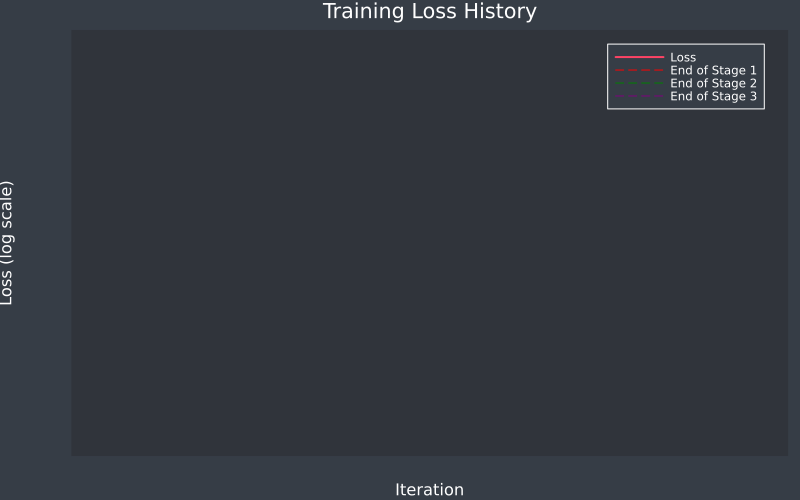

In [12]:
# --- VISUALIZE TRAINING HISTORY ---

# Create a plot of the loss history on a logarithmic scale
plot(all_losses,
    yscale=:log10,
    xlabel="Iteration",
    ylabel="Loss (log scale)",
    title="Training Loss History",
    label="Loss",
    legend=:topright,
    linewidth=2,
    size=(800, 500) # Set a nice plot size
)

# Add vertical lines to mark the end of each training stage
vline!([2000], label="End of Stage 1", color=:red, linestyle=:dash)
vline!([5000], label="End of Stage 2", color=:green, linestyle=:dash)
vline!([7000], label="End of Stage 3", color=:purple, linestyle=:dash) # Added for the new stage

# Display the plot
current()


### plot the sythetic data VS NN data

In [23]:
# --- Cell 3: Data Generation ---

# 2D Hodgkin-Huxley reduced model engine
function hodgkin_huxley_reduced!(du, u, p, t)
    V, n = u
    I_ext = Stimulus(t)


    # Known 2D current
    I_Na = g_Na * m_inf(V)^3 * h_inf(V) * (V - E_Na)
    I_K  = g_K  * n^4 * (V - E_K)
    I_L  = g_L * (V - E_L)
    du[1] = (I_ext - I_Na - I_K - I_L) / Cm
    du[2] = (n_inf(V) - n) / tau_n(V)
end

# Generate Data
u0_true = [-65.0, n_inf(-65.0)]
tspan = (0.0, 50.0)
prob_true = ODEProblem(hodgkin_huxley_reduced!, u0_true, tspan)
sol_true = solve(prob_true, Rodas5P(), saveat=0.5)

# Extract and structure the training data
data_V = sol_true[1, :]
t_train = sol_true.t
data_n=sol_true[2, :]

# (Optional) Verify data shape and content
df = DataFrame(t=t_train, V=data_V , n=data_n )
println("Generated Training Data:")
display(first(df, 5))

MethodError: MethodError: no method matching n_inf(::Float64)
The function `n_inf` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  n_inf(!Matched::Float32)
   @ Main c:\Users\nirbh\Neural_Spiking_Dynamics\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:16


In [24]:
using JLD2

In [25]:
theme(:dark)


In [26]:
@save "hh_solution.jld2" sol_true data_V t_train


UndefVarError: UndefVarError: `sol_true` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [27]:
@load "hh_solution.jld2" sol_true data_V t_train


KeyError: KeyError: key "sol_true" not found

In [28]:
plot(
    df.t,
    df.n,
    xlabel = "Time (ms)",
    ylabel = "n-gate",
    title = "Potassium Gate n(t)",
    legend = false,
    linewidth = 2,
    color = :red
)


UndefVarError: UndefVarError: `df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing Rmath in the current active module Main

In [29]:
plot(t_train,data_V)

UndefVarError: UndefVarError: `t_train` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [30]:
using JLD2

In [31]:
nn_data=load("neuron_best_model.jld2")
nn_parameter=nn_data["params"]

ArgumentError: ArgumentError: No file exists at given path: neuron_best_model.jld2

In [32]:
nn_model = Chain(
    Dense(1,15, tanh,init = Flux.glorot_uniform),
    # Dense(15,30,tanh,init = Flux.glorot_uniform),
    Dense(15,1,init=Flux.glorot_uniform)
) |> Flux.f64 # Explicitly convert network to Float64



Chain(
  Dense(1 => 15, tanh),                 # 30 parameters
  Dense(15 => 1),                       # 16 parameters
)                   # Total: 4 arrays, 46 parameters, 576 bytes.

In [33]:
using Flux.Optimise: restructure


In [34]:
f, re = Flux.destructure(nn_model)


([0.6062900424003601, 0.0658089891076088, -0.5513072609901428, -0.013553416356444359, -0.5699418783187866, -0.01031146477907896, 0.044858288019895554, 0.5300484299659729, -0.33324211835861206, -0.05168522149324417  …  0.005249246023595333, -0.3837352395057678, 0.16512614488601685, 0.31844979524612427, -0.464976966381073, 0.23673371970653534, 0.5214448571205139, -0.3566095530986786, 0.13456274569034576, 0.0], Restructure(Chain, ..., 46))

In [35]:


# Define the UDE function with the embedded neural network
function ude_dynamics!(du, u, p, t)
    V, n = u
    # p --> p_nn neural network parameters
    # Neural network component to learn the unknown current
    # we will normalize V roughly ( divide by 100) to keep inputs clean for the NN

    nn_input = V / 100.0
    # We divide V by 100.0 to keep inputs small for the Neural Network
    # Example: -65mV becomes -0.65

    nn_I_Na = re(p)([nn_input])[1]
    # Known physics components
    I_ext = Stimulus(t)
    I_K  = g_K  * n^4 * (V - E_K)
    I_L  = g_L * (V - E_L)
    
    # The hybrid dynamics equation
    du[1] = (I_ext + nn_I_Na - I_K - I_L) / Cm
    du[2] = (n_inf(V) - n) / tau_n(V)
end
println("Hybrid Engine Assembled.")

Hybrid Engine Assembled.


In [36]:
# Solve Hybrid UDE
u0 = [-65.0, n_inf(-65.0)]
tspan = (0.0, 50.0)
prob_ude = ODEProblem(ude_dynamics!, u0_true, tspan, nn_parameter)

# Solve the UDE
println("Solving UDE with trained parameters...")
sol_ude = solve(prob_ude, Rodas5P(), saveat=0.1)
println("Done.")

MethodError: MethodError: no method matching n_inf(::Float64)
The function `n_inf` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  n_inf(!Matched::Float32)
   @ Main c:\Users\nirbh\Neural_Spiking_Dynamics\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:16


In [37]:
# Y_target: The output the NN produced at that exact voltage
# This is what we are trying to equate to a formula
Y_target = [trained_NN([v/100])[1] for v in V_t]

UndefVarError: UndefVarError: `V_t` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [38]:

println("📊 Harvest Complete. Collected $(length(V_t)) data points from the trajectory.")

UndefVarError: UndefVarError: `V_t` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [39]:
data_SR=DataFrame(t_val= sol_ude.t,V_T=V_t,Y_Target=Y_target)

UndefVarError: UndefVarError: `sol_ude` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [41]:
using  Plots
theme(:dark)

p1 = plot(data_SR.t_val,data_SR.V_T,label="predicted action potential ",lw=2,xlabel="Time (ms)",
  ylabel="Voltage )")
p2 = plot(df.t,df.V,label="True action potential ",color=:cyan,lw=2,xlabel="Time (ms)",
  ylabel="Voltage )")
plot(p1,p2)


UndefVarError: UndefVarError: `data_SR` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [42]:
# ture Voltage spike vs predicted spike

plot(df.t, df.V, 
    label="True Voltage", 
    linewidth=3,
    color=:cyan)

plot!(data_SR.t_val, data_SR.V_T,
    label="Predicted Voltage",
    linewidth=2,
    color=:yellow,
    linestyle=:dash)




UndefVarError: UndefVarError: `df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing Rmath in the current active module Main

In [43]:
p2 = plot(data_SR.t_val, data_SR.Y_Target, 
    label="NN Output (Target Current)", 
    color=:cyan, lw=2,
    xlabel="Time (ms)", 
    ylabel="Current (µA/cm²)",
    title="The Learned Signal vs. Time",
    legend=:topright)

UndefVarError: UndefVarError: `data_SR` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [44]:
p2_twin = twinx(p2)

UndefVarError: UndefVarError: `p2` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [45]:
plot!(p2_twin, data_SR.t_val, data_SR.V_T, 
    label="Voltage Trace", 
    color=:red, alpha=0.5, ls=:dash, 
    ylabel="Voltage (mV)", legend=:bottomright)

UndefVarError: UndefVarError: `p2_twin` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [46]:
p2 = plot(V_t, Y_target,
    seriestype=:scatter, # Show individual data points
    label="Harvested Data Points",
    markercolor=:orange, markersize=3, markeralpha=0.6,
    xlabel="Membrane Voltage (mV)",
    ylabel="Predicted Current",
    title="The Hidden Structure: I vs V Curve")

UndefVarError: UndefVarError: `V_t` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [47]:
# Add a line to show the trajectory order
plot!(p2, V_t, Y_target, color=:Red, alpha=0.3, label="Trajectory Path")

UndefVarError: UndefVarError: `p2` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [48]:

# --- COMBINE & DISPLAY ---
l = @layout [a; b]
display(plot(p1, p2, layout=l, size=(800, 800)))

UndefVarError: UndefVarError: `p1` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Ok lets move to symbolic discovery 

In [49]:
using Convex
using SCS
using Symbolics
using Printf

println("⚔️ INITIATING SYMBOLIC REGRESSION: THE HARVEST STRATEGY ⚔️")

ArgumentError: ArgumentError: Package SCS not found in current path.
- Run `import Pkg; Pkg.add("SCS")` to install the SCS package.

### Calculating the building blocks

## all the biophysical constants and functions has been already defined

In [50]:
    data = load("neuron_best_model.jld2")
    best_params = data["params"]

ArgumentError: ArgumentError: No file exists at given path: neuron_best_model.jld2

In [51]:
# Rebuild the trained network
_, re = Flux.destructure(U)
trained_NN = re(best_params)

UndefVarError: UndefVarError: `best_params` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [52]:
# We must replicate the UDE Dynamics function to generate the trajectory
function ude_dynamics!(du, u, p, t)
    V, n = u
    # Use the NN to predict current (Input scaled by 100 as per training!)
    nn_I_Na = trained_NN([V / 100.0])[1]
    
    I_ext = (t >= 10.0 && t < 11.0) ? 20.0 : 0.0
    I_K   = g_K * n^4 * (V - E_K)
    I_L   = g_L * (V - E_L)
    
    du[1] = (I_ext + nn_I_Na - I_K - I_L) / Cm
    du[2] = (n_inf(V) - n) / tau_n(V)
end


ude_dynamics! (generic function with 1 method)

In [53]:
# Solve over the spike duration
u0 = [-65.0, n_inf(-65.0)]
tspan = (0.0, 50.0)
prob = ODEProblem(ude_dynamics!, u0, tspan, best_params)
sol = solve(prob, Rodas5(), saveat=0.1)

MethodError: MethodError: no method matching n_inf(::Float64)
The function `n_inf` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  n_inf(!Matched::Float32)
   @ Main c:\Users\nirbh\Neural_Spiking_Dynamics\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:16


In [54]:
# Extract Data vectors
V_t = sol[1, :] # Voltage trajectory

UndefVarError: UndefVarError: `sol` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [55]:
plot(V_t)

UndefVarError: UndefVarError: `V_t` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [56]:
Y_current = [trained_NN([v / 100])[1] for v in V_t]


UndefVarError: UndefVarError: `V_t` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [57]:
plot(Y_current)

UndefVarError: UndefVarError: `Y_current` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [58]:
# Run this immediately after loading the model
println("--- DIAGNOSTIC CHECK ---")

# 1. Check a Resting Voltage (-65.0)
v_rest = -65.0
pred_rest = trained_NN([v_rest / 100.0])[1] # Check with scaling
pred_rest_raw = trained_NN([v_rest])[1]     # Check without scaling

println("Neural Net Output at Rest (-65mV):")
println("   With /100 scaling: $pred_rest")
println("   Raw input:         $pred_rest_raw")

# 2. Check an Excited Voltage (-40.0)
v_excited = -40.0
pred_excited = trained_NN([v_excited / 100.0])[1]
println("Neural Net Output at Excitement (-40mV) [Scaled]: $pred_excited")

println("------------------------")

--- DIAGNOSTIC CHECK ---


UndefVarError: UndefVarError: `trained_NN` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [59]:
using DifferentialEquations, Flux, Plots, JLD2, Printf

println("🧪 STEP 1: CORRECTED HARVEST 🧪")

# --- LOAD INTEL ---
if !isfile("neuron_best_model.jld2")
    error("Run training first!")
end
data = load("neuron_best_model.jld2")
_, re = Flux.destructure(U)
trained_NN = re(data["params"])

# --- PHYSICS CONSTANTS ---
const Cm = 1.0; const E_Na = 50.0; const E_K = -77.0; const E_L = -54.387
const g_K = 36.0; const g_L = 0.3
α_n(V) = 0.01 * (V + 55) / (1 - exp(-(V + 55) / 10))
β_n(V) = 0.125 * exp(-(V + 65) / 80)
n_inf(V) = α_n(V) / (α_n(V) + β_n(V))
tau_n(V) = 1 / (α_n(V) + β_n(V))

# --- THE CORRECTED ENGINE ---
function ude_dynamics_corrected!(du, u, p, t)
    V, n = u
    # NN Input: Scaled Voltage
    nn_I_Na = trained_NN([V / 100.0])[1]
    
    # Physics Input: Stimulus
    I_ext = (t >= 10.0 && t < 11.0) ? 20.0 : 0.0
    I_K   = g_K * n^4 * (V - E_K)
    I_L   = g_L * (V - E_L)
    
    # CRITICAL FIX: FLIPPED SIGN to (+)
    # The NN output (+68) effectively acts as 'Depolarizing Current'
    du[1] = (I_ext + nn_I_Na - I_K - I_L) / Cm
    du[2] = (n_inf(V) - n) / tau_n(V)
end

# --- RUN SIMULATION ---
u0 = [-65.0, n_inf(-65.0)]
tspan = (0.0, 50.0)
prob = ODEProblem(ude_dynamics_corrected!, u0, tspan, data["params"])
sol = solve(prob, Rodas5P(), saveat=0.1)

# Extract trajectory
V_t = sol[1, :]
# Calculate what the NN thinks along this trajectory
Y_target = [trained_NN([v/100.0])[1] for v in V_t]

# Plot to verify
p1 = plot(sol.t, V_t, title="Voltage (Spike Verification)", label="V(t)", color=:red, lw=2)
p2 = plot(sol.t, Y_target, title="NN Output (Harvested)", label="NN(V)", color=:cyan, lw=2)
display(plot(p1, p2, layout=(2,1)))

println("Harvest Data Points: $(length(Y_target))")
println("Peak Voltage: $(maximum(V_t)) mV")

🧪 STEP 1: CORRECTED HARVEST 🧪


ErrorException: Run training first!

In [60]:
using DifferentialEquations, Flux, Optimization, OptimizationOptimJL, JLD2, Plots, Statistics

println("🧪 STEP 1: SMART HARVEST 🧪")

# --- PHYSICS SETUP ---
const Cm = 1.0; const E_Na = 50.0; const E_K = -77.0; const E_L = -54.387; const g_K = 36.0; const g_L = 0.3
const g_Na = 120.0
α_n(V) = 0.01 * (V + 55) / (1 - exp(-(V + 55) / 10)); β_n(V) = 0.125 * exp(-(V + 65) / 80)
α_m(V) = 0.1 * (V + 40) / (1 - exp(-(V + 40) / 10)); β_m(V) = 4.0 * exp(-(V + 65) / 18)
α_h(V) = 0.07 * exp(-(V + 65) / 20); β_h(V) = 1 / (1 + exp(-(V + 35) / 10))
m_inf(V) = α_m(V) / (α_m(V) + β_m(V)); h_inf(V) = α_h(V) / (α_h(V) + β_h(V))
n_inf(V) = α_n(V) / (α_n(V) + β_n(V)); tau_n(V) = 1 / (α_n(V) + β_n(V))

# Define Pulse for Training comparison
stimulus_fn(t) = (t >= 10.0 && t < 11.0) ? 20.0 : 0.0

# --- RECONSTRUCT GROUND TRUTH (Validation Data) ---
# We need this to repair the model if it's broken
function truth_physics!(du, u, p, t)
    V, n = u
    I_Na = g_Na * m_inf(V)^3 * h_inf(V) * (V - E_Na)
    du[1] = (stimulus_fn(t) - I_Na - g_K*n^4*(V-E_K) - g_L*(V-E_L))/Cm
    du[2] = (n_inf(V) - n)/tau_n(V)
end
prob_true = ODEProblem(truth_physics!, [-65.0, n_inf(-65.0)], (0.0, 50.0))
truth_sol = solve(prob_true, Rodas5P(), saveat=0.5)
data_V = truth_sol[1,:] # The standard we must reach

# --- UDE DYNAMICS ---
U = Chain(Dense(1, 15, tanh), Dense(15, 1))
p_init, re = Flux.destructure(U)

function ude_dynamics!(du, u, p, t)
    V, n = u
    nn_I_Na = re(p)([V/100.0])[1] # With scaling
    I_ext = stimulus_fn(t)
    # Using (+) Sign because we expect NN to learn 'Depolarizing' signal logic
    du[1] = (I_ext + nn_I_Na - g_K*n^4*(V-E_K) - g_L*(V-E_L)) / Cm 
    du[2] = (n_inf(V) - n) / tau_n(V)
end

# --- CHECK AND REPAIR ---
if isfile("neuron_best_model.jld2")
    loaded_data = load("neuron_best_model.jld2")
    current_p = loaded_data["params"]
    println("📂 Loaded model params.")
else
    println("⚠️ No save file found. Using random init.")
    current_p = p_init
end

# Test run
test_prob = ODEProblem(ude_dynamics!, [-65.0, n_inf(-65.0)], (0.0, 50.0), current_p)
test_sol = solve(test_prob, Rodas5P(), saveat=0.5)

if maximum(test_sol[1,:]) < -20.0
    println("🚨 ALERT: Model is asleep (No Spike detected). Initiating Rapid Repair...")
    
    function loss_repair(p)
        pred = solve(remake(test_prob, p=p), Rodas5P(), saveat=0.5, 
                     sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()))
        if pred.retcode != :Success; return 1e6; end
        return sum(abs2, pred[1,:] .- data_V)
    end
    
    optf = Optimization.OptimizationFunction((x,p)->loss_repair(x), Optimization.AutoZygote())
    optprob = Optimization.OptimizationProblem(optf, current_p)
    # Fast Polish
    res = Optimization.solve(optprob, OptimizationOptimJL.LBFGS(), maxiters=500)
    global current_p = res.u
    println("✅ Repair Complete. Loss: $(res.objective)")
else
    println("✅ Model is Healthy (Spike detected).")
end

# --- FINAL HARVEST ---
prob_final = ODEProblem(ude_dynamics!, [-65.0, n_inf(-65.0)], (0.0, 50.0), current_p)
sol_final = solve(prob_final, Rodas5P(), saveat=0.1)
V_t = sol_final[1,:]
Y_target = [re(current_p)([v/100.0])[1] for v in V_t]

# Plot results
p1 = plot(sol_final.t, V_t, label="V(t) Repair", title="Corrected Trajectory", lw=2, color=:red)
p2 = plot(sol_final.t, Y_target, label="NN Current", title="Harvested Signal", lw=2, color=:cyan)
display(plot(p1, p2, layout=(2,1)))

println("Peak NN Output: $(maximum(abs.(Y_target)))")

🧪 STEP 1: SMART HARVEST 🧪


ErrorException: invalid redefinition of constant Main.E_Na

In [73]:
nn_data_V=sol_[1, :] 
t_train=sol_true.t
nn_data_n=sol_true2[2, :]
df2 = DataFrame(t = t_train, V = data_V,n=nn_data_n)

UndefVarError: UndefVarError: `sol_` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [74]:
plot(df2.t,df.V)

UndefVarError: UndefVarError: `df2` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [75]:
    plot(
        t_train,
        sol_true[2, :],
        xlabel = "Time (ms)",
        ylabel = "n-gate",
        title = "Potassium Gate n(t)",
        legend = false,
        linewidth = 2,
        color = :red
    )


UndefVarError: UndefVarError: `sol_true` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## Final Plot


In [76]:
ude_V = sol_ude[1, :]
ude_n = sol_ude[2, :]

# Extract the true solution trajectories for comparison
true_V = sol_true[1, :]
true_n = sol_true[2, :]

# Compute the error
V_error = true_V .- ude_V
n_error = true_n .- ude_n

UndefVarError: UndefVarError: `sol_ude` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [77]:
# Computing the error

V_error = true_V .-ude_V
n_error= true_n .-ude_n

UndefVarError: UndefVarError: `true_V` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [78]:
using Statistics

In [79]:

println("Mean Absolute Voltage Error: ", mean(abs.(V_error)))
println("Mean Absolute n-gate Error:  ", mean(abs.(n_error)))

UndefVarError: UndefVarError: `V_error` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [80]:
theme(:dark)

In [81]:

# --------------- voltage plot -----------
p1=plot(sol_ude.t,true_V, label = "Ground Truth" , color=:cyan
, linewidth = 3, title="Model Discovery Comparison", xlabel=" Time (ms)",
ylabel = "Voltage (mV)" )

p2=plot!(p1,sol_ude.t, ude_V,color=:yellow,linestyle=:dash, linewidth=2)




# p5=plot(p1,p3,p2,p4
#     ,layout = (2,2),
#     size =(1200, 900),
#     margin = 5,
#     legendfontsize = 8,
#     title = "UDE Model vs True Hodgkin-Huxley Model")
#     display(p5)


UndefVarError: UndefVarError: `sol_ude` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [82]:
# ------ n gate plot -----------

p3=plot(sol_ude.t,true_n, label = "Ground Truth" , color=:white
, linewidth = 3, title="Model Discovery Comparison", xlabel=" Time (ms)",
ylabel = "Voltage (mV)" )

p4 = plot!(p3,sol_ude.t, ude_n,color=:blue,linestyle=:dash, linewidth=2)


UndefVarError: UndefVarError: `sol_ude` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [83]:
# ploting for Voltage Error

# Plot for Voltage Error
p_V_error = plot(t_train, V_error,
    label = "Voltage Error (True - UDE)",
    title = "Prediction Error Over Time",
    xlabel = "Time (ms)",
    ylabel = "Voltage Error (mV)",
    color = :red,
    legend = :topright)

UndefVarError: UndefVarError: `t_train` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [84]:
hline!(p_V_error, [0.0], linestyle=:dash, color=:white, label="Zero Error") # Add a zero line for reference

UndefVarError: UndefVarError: `p_V_error` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [85]:
# Plot for n-gate Error
p_n_error = plot(t_train, n_error,
    label = "n-gate Error (True - UDE)",
    xlabel = "Time (ms)",
    ylabel = "n-gate Error",
    color = :orange,
    legend = :bottomright)
hline!(p_n_error, [0.0], linestyle=:dash, color=:white, label="Zero Error") # Add a zero line


UndefVarError: UndefVarError: `t_train` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [86]:
# Combine both plots into a single figure with a vertical layout
p_error_layout = plot(p_V_error, p_n_error, layout = (2, 1), size = (800, 600))

# Display the final layout
display(p_error_layout)

UndefVarError: UndefVarError: `p_V_error` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [87]:
# --- Final Comparison Plot: UDE vs. Ground Truth ---

# 1. Create the Voltage Comparison Plot
p_V_comp = plot(t_train, true_V,
    label = "Ground Truth V(t)",
    title = "Voltage Trajectory Comparison",
    xlabel = "Time (ms)",
    ylabel = "Voltage (mV)",
    color = :cyan,
    linewidth = 3,
    legend = :topleft)

plot!(p_V_comp, t_train, ude_V,
    label = "UDE Prediction V(t)",
    color = :orange,
    linestyle = :dash,
    linewidth = 2)

# 2. Create the n-gate Comparison Plot
p_n_comp = plot(t_train, true_n,
    label = "Ground Truth n(t)",
    title = "Potassium Gate n(t) Comparison",
    xlabel = "Time (ms)",
    ylabel = "n-gate activation",
    color = :lightgreen,
    linewidth = 3,
    legend = :topleft)

plot!(p_n_comp, t_train, ude_n,
    label = "UDE Prediction n(t)",
    color = :magenta,
    linestyle = :dash,
    linewidth = 2)

# 3. Combine both plots into a single layout
p_combined = plot(p_V_comp, p_n_comp, layout = (2, 1), size = (800, 700))

# 4. Display the final combined plot
display(p_combined)

UndefVarError: UndefVarError: `t_train` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# let's do the symbolic regression

In [88]:
using Convex
using SCS
using Symbolics
using Printf



ArgumentError: ArgumentError: Package SCS not found in current path.
- Run `import Pkg; Pkg.add("SCS")` to install the SCS package.

In [89]:
# 1. Create a detailed Voltage scan (from -90mV to +40mV)
V_scan = -90.0 : 0.5 :  30.0

# 2. Pre-calculate the m and h gating values for every point in that scan
# These are the "bricks" we will use to build our equation.
m_vals = m_inf.(V_scan)
h_vals = h_inf.(V_scan)

MethodError: MethodError: no method matching m_inf(::Float64)
The function `m_inf` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  m_inf(!Matched::Float32)
   @ Main c:\Users\nirbh\Neural_Spiking_Dynamics\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:14


In [90]:
_, re = Flux.destructure(U)
recruit = re(nn_parameter)
pred_I_Na = [recruit([V])[1] for V in V_scan]

UndefVarError: UndefVarError: `nn_parameter` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [91]:
E_Na = 50.0
V_scan = -90.0 : 0.5 :  30.0  
pred_G_Na= pred_I_Na./(V_scan .-E_Na)

# println(" Move 1 complete : Neural Network data converted to conductance. ")

ErrorException: invalid redefinition of constant Main.E_Na

In [92]:
pred_G_Na

UndefVarError: UndefVarError: `pred_G_Na` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [93]:
function get_m(v)
    
    alpha = (abs(v+40) < 1e-5) ?
         1.0 :
         0.1 * (v+40) / (1 - exp(-(v+40)/10))

     beta = 4.0 * exp(-(v + 65) / 18)

    return alpha / (alpha + beta)
end

function get_h(v)
    alpha = 0.07 * exp(-(v + 65) / 20)
    beta  = 1 / (1 + exp(-(v + 35) / 10))
    return alpha / (alpha + beta)
end


get_h (generic function with 1 method)

## Design matrix with 25 basis function 

In [94]:
using Symbolics, LinearAlgebra

In [95]:
# We define THE input variable (m and h)

# u[1] ---> m_inf(v)
# u[2] ---> h_inf(v)
 @variables u1 u2
basis_funcs = [
    # Degree 0
    u -> 1.0,
    
    # Degree 1
    u -> u[1],
    u -> u[2],
    
    # Degree 2
    u -> u[1]^2,
     u -> u[1]*u[2], 
     u -> u[2]^2,
    
    # Degree 3
    u -> u[1]^3,
     u -> u[1]^2*u[2],
      u -> u[1]*u[2]^2,
       u -> u[2]^3,
    
    # Degree 4 
    u -> u[1]^4, 
    u -> u[1]^3*u[2],   #  --> we want this 
    u -> u[1]^2*u[2]^2, 
    u -> u[1]*u[2]^3, 
    u -> u[2]^4,
    
    # Degree 5 (Distractors)
    u -> u[1]^5,
     u -> u[1]^4*u[2], 
     u -> u[1]^3*u[2]^2,
      u -> u[1]^2*u[2]^3,
       u -> u[1]*u[2]^4,
        u -> u[2]^5,
    
    # Degree 6 (Heavy Distractors)
    u -> u[1]^6, 
    u -> u[1]^5*u[2], 
    u -> u[1]^4*u[2]^2, 
    u -> u[1]^3*u[2]^3, 
    u -> u[1]^2*u[2]^4, 
    u -> u[1]*u[2]^5, 
    u -> u[2]^6
]
println("Library of basis fuction has been created . Total Candidate Functions: $(length(basis_funcs))")


Library of basis fuction has been created . Total Candidate Functions: 28


In [96]:
@variables u1 u2


basis_symbols = [
    1,              # Degree 0
    
    u1,
     u2,         # Degree 1

    u1^2,
     u1*u2,
      u2^2,                        # Degree 2

    u1^3,
     u1^2*u2, 
     u1*u2^2, 
     u2^3,              # Degree 3

    u1^4,
     u1^3*u2,
      u1^2*u2^2,
       u1*u2^3,
        u2^4,   # Degree 4

    u1^5,
     u1^4*u2, 
     u1^3*u2^2, 
     u1^2*u2^3,
    u1*u2^4, 
    u2^5,                             # Degree 5

    u1^6,
     u1^5*u2,
     u1^4*u2^2, 
     u1^3*u2^3,
    u1^2*u2^4, 
    u1*u2^5, u2^6                   # Degree 6
]


28-element Vector{Num}:
             1
            u1
            u2
          u1^2
         u1*u2
          u2^2
          u1^3
     (u1^2)*u2
     u1*(u2^2)
          u2^3
             ⋮
     u1*(u2^4)
          u2^5
          u1^6
     (u1^5)*u2
 (u1^4)*(u2^2)
 (u1^3)*(u2^3)
 (u1^2)*(u2^4)
     u1*(u2^5)
          u2^6

# Preparing the Data for Design Matrix (Φ)


In [97]:
Phi_T = zeros(length(basis_funcs), length(V_scan))

for j in 1:length(V_scan)
          v=V_scan[j]
          u_inputs = [get_m(v) , get_h(v)]



          for i in 1:length(basis_funcs)
                    Phi_T[i,j] = basis_funcs[i](u_inputs)
          end
end


Phi = Phi_T'





241×28 adjoint(::Matrix{Float64}) with eltype Float64:
 1.0  0.00210994  0.983614     4.45184e-6  …  0.00194265   0.905626
 1.0  0.00225824  0.982364     5.09964e-6     0.00206601   0.898742
 1.0  0.00241674  0.981021     5.84061e-6     0.00219594   0.891393
 1.0  0.00258611  0.979577     6.68795e-6     0.0023326    0.883553
 1.0  0.00276708  0.978027     7.65672e-6     0.00247614   0.875195
 1.0  0.00296042  0.976362     8.76407e-6  …  0.00262668   0.866293
 1.0  0.00316694  0.974574     1.00295e-5     0.00278429   0.85682
 1.0  0.00338752  0.972656     1.14753e-5     0.00294902   0.846749
 1.0  0.00362308  0.970597     1.31267e-5     0.00312085   0.836053
 1.0  0.00387459  0.968389     1.50125e-5     0.00329971   0.824706
 ⋮                                         ⋱               
 1.0  0.996157    0.000740814  0.992329       2.22267e-16  1.65293e-19
 1.0  0.99629     0.000722458  0.992593       1.96087e-16  1.42192e-19
 1.0  0.996418    0.00070456   0.992848       1.72994e-16  1.223

In [98]:
size(pred_G_Na)

UndefVarError: UndefVarError: `pred_G_Na` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [99]:
size(Phi)         # returns (241, 28)
length(pred_G_Na) # returns 241
coeffs = rand(28) # example coefficient vector of length 28



UndefVarError: UndefVarError: `pred_G_Na` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [100]:
# Matrix-vector multiplication
Phi * coeffs      # returns a vector of length 241



UndefVarError: UndefVarError: `coeffs` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [101]:
# Check compatibility
length(Phi * coeffs) == length(pred_G_Na)  # returns true

UndefVarError: UndefVarError: `coeffs` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [102]:
coeffs = Convex.Variable(size(Phi,2))

Variable
size: (28, 1)
sign: real
vexity: affine
id: 154…478

In [103]:
target = pred_G_Na
lambda=1e-4

loss_term = sumsquares(Phi * coeffs - target)
reg_term  = lambda * norm(coeffs, 1)


problem = minimize(loss_term+reg_term)

UndefVarError: UndefVarError: `pred_G_Na` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [104]:
Convex.solve!(problem, SCS.Optimizer)

UndefVarError: UndefVarError: `problem` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [105]:
c_vals = vec(evaluate(coeffs))


ErrorException: Value of the variable is yet to be calculated

In [106]:
for (i, val) in enumerate(c_vals)
    println(rpad(basis_symbols[i], 12), " -> ", round(val, digits=6))
end

UndefVarError: UndefVarError: `c_vals` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [107]:
# 3) List only the "strong" terms (threshold adjustable)
threshold = 0.4   # start at 0.5; lower it if you expect smaller coeffs
println("\nStrong terms (|coef| >", threshold, "):")
for (i, val) in enumerate(c_vals)
    if abs(val) > threshold
        println("  ", basis_symbols[i], "  coef = ", round(val, digits=6))
    end
end


Strong terms (|coef| >0.4):


UndefVarError: UndefVarError: `c_vals` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [108]:
# Reconstruct and measure fit
c_vals = vec(evaluate(coeffs))             # (already available but safe to recompute)
reconstructed_G = Phi * c_vals             # 241-element vector

using Statistics
rmse = sqrt(mean((reconstructed_G .- pred_G_Na).^2))
r2   = 1 - sum((reconstructed_G .- pred_G_Na).^2) / sum((pred_G_Na .- mean(pred_G_Na)).^2)

println("RMSE = ", rmse)
println("R^2  = ", round(r2, digits=6))


ErrorException: Value of the variable is yet to be calculated

In [109]:
using Plots
plot(V_scan, pred_G_Na, label="NN G(V)", lw=3)
plot!(V_scan, reconstructed_G, label="Phi·c (discovered)", lw=2, linestyle=:dash)
title!("NN vs Discovered Conductance"); xlabel!("V (mV)"); ylabel!("G")


UndefVarError: UndefVarError: `pred_G_Na` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

#### we are using standardization (Φ) and center y , so that LASSO GIVE IMPORTANCE TO EACH TERM AND DO NO WIPE OUT THE TERM WITH LOW VALUE

In [110]:
mu = mean(Phi, dims=1)
σ  = std(Phi, dims=1, corrected=false)


1×28 Matrix{Float64}:
 0.0  0.405826  0.348316  0.421815  …  9.98622e-5  0.00233247  0.245672

In [111]:
σ .< 1e-12] .= 1.0


Base.Meta.ParseError: ParseError:
# Error @ c:\Users\nirbh\Neural_Spiking_Dynamics\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y231sZmlsZQ==.jl:1:11
σ .< 1e-12] .= 1.0
#         └──────┘ ── extra tokens after end of expression

In [112]:
Phi_std  = (Phi .- mu)./σ
norms = norm.(eachcol(Phi_std))
println("Phi_std = " , norms)

Phi_std = [NaN, 15.524174696260024, 15.524174696260024, 15.524174696260026, 15.524174696260024, 15.524174696260022, 15.524174696260019, 15.524174696260026, 15.524174696260024, 15.524174696260022, 15.524174696260024, 15.524174696260024, 15.524174696260022, 15.524174696260028, 15.524174696260022, 15.524174696260026, 15.524174696260024, 15.524174696260024, 15.524174696260024, 15.524174696260026, 15.524174696260019, 15.524174696260019, 15.524174696260015, 15.524174696260019, 15.52417469626002, 15.524174696260028, 15.524174696260019, 15.524174696260031]


In [113]:
println(norm.(eachcol(Phi_s)))


UndefVarError: UndefVarError: `Phi_s` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [114]:
println("Column norms (should be ~1):")
println(norm.(eachcol(Phi_s)))


Column norms (should be ~1):


UndefVarError: UndefVarError: `Phi_s` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [115]:
println(size(Phi))


(241, 28)


In [116]:
println("mean = ", mean(Phi , dims=1))
println("standard_deviation  = ", std(Phi , dims=1))

mean = [1.0 0.5739871772974989 0.23736822078339068 0.4941563258991231 0.01374644532470413 0.17766740575492004 0.4515229686347181 0.004459828516492658 0.0040353391607169335 0.14990961172037565 0.4221187891798373 0.0026774023574319397 0.0003715701342845871 0.0023220861750018994 0.13190777807276619 0.39957140260127816 0.001981302913993544 8.948905122000869e-5 0.00010941135321571766 0.0016295611544123606 0.11868658821869527 0.38124423009931835 0.001607236892591864 3.734438003292277e-5 1.2220977917173886e-5 5.206632250438655e-5 0.0012526656590926763 0.10830690261743398]
standard_deviation  = [0.0 0.40667096719132473 0.349040469105473 0.4226933672674049 0.013541278778224322 0.3174274136989492 0.4220311430728039 0.004186530296863186 0.005994285072512612 0.29358414916935477 0.418273986217157 0.002584268517184415 0.0005444946727416669 0.0038913584564058564 0.27489252545385645 0.41367409740471905 0.0019672888439182046 0.00012537999832433743 0.0001931724731455516 0.0029101456811432115 0.259429877

In [117]:
# --- 1. Separate Intercept from Features ---
# The first column of Phi is the intercept (all ones)
feature_matrix = Phi[:, 2:end]
feature_symbols = basis_symbols[2:end]

# --- 2. Standardize ONLY the features ---
mu_features = mean(feature_matrix, dims=1)
σ_features  = std(feature_matrix, dims=1, corrected=false)
# Prevent division by zero for any constant feature columns
σ_features[σ_features .< 1e-12] .= 1.0
Phi_std = (feature_matrix .- mu_features) ./ σ_features

# Verify the norms of the STANDARDIZED FEATURES
# Each norm should be approximately sqrt(241) ≈ 15.52
feature_norms = norm.(eachcol(Phi_std))
println("Norms of standardized feature columns (all should be non-zero):")
display(feature_norms)

27-element Vector{Float64}:
 15.524174696260026
 15.52417469626002
 15.524174696260026
 15.524174696260026
 15.524174696260026
 15.524174696260024
 15.524174696260022
 15.524174696260022
 15.524174696260019
 15.524174696260022
  ⋮
 15.524174696260026
 15.524174696260017
 15.524174696260019
 15.524174696260026
 15.524174696260022
 15.524174696260022
 15.524174696260022
 15.524174696260026
 15.524174696260026

Norms of standardized feature columns (all should be non-zero):


In [118]:
# --- 3. Center the target variable ---
y = pred_G_Na
y_mean = mean(y)
y_centered = y .- y_mean

UndefVarError: UndefVarError: `pred_G_Na` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [119]:
using Statistics
using LinearAlgebra
using Plots

# --- 1. SETUP ---
y = vec(pred_G_Na)
X = Phi_T' 
basis_names = basis_symbols

println("🛡️ INITIATING ARTIFACT FILTRATION PROTOCOL 🛡️")

# --- 2. THE SURGICAL STRIKE (Data Cleaning) ---
# We calculate the mean and standard deviation.
# Anything that is wildly far from the average is an Artifact (The Spike).

mu_y, sigma_y = mean(y), std(y)

# We keep only data points within 1 standard deviation of the mean.
# (The spike is likely 5-10 sigmas away).
mask = abs.(y .- mu_y) .< (1.0 * sigma_y)

# Apply the mask to both X and y
y_clean = y[mask]
X_clean = X[mask, :]

println("Original Data Points: $(length(y))")
println("Cleaned Data Points:  $(length(y_clean))")
println("Artifacts Removed:    $(length(y) - length(y_clean))")

# --- 3. RE-NORMALIZE THE CLEAN DATA ---
y_mean_c, y_std_c = mean(y_clean), std(y_clean)
y_norm = (y_clean .- y_mean_c) ./ y_std_c

X_mean_c = mean(X_clean, dims=1)
X_std_c  = std(X_clean, dims=1)
X_std_c[X_std_c .== 0] .= 1.0
X_norm = (X_clean .- X_mean_c) ./ X_std_c

# --- 4. RUN STRidge ON CLEAN DATA ---
# We use the Stable STRidge function defined in the previous step
# If you lost the function definition, re-run the previous code block first!
# We set lambda slightly lower (0.1) because the data is now cleaner.
norm_coeffs = STRidge_Stable(X_norm, y_norm, lam=0.1, threshold=0.05)

# --- 5. DE-NORMALIZE ---
final_coeffs = (norm_coeffs ./ vec(X_std_c)) .* y_std_c

# --- 6. REPORT ---
println("\n🔎 DISCOVERY REPORT (Artifacts Removed):")
println("------------------------------------------------")
found_any = false
for (i, val) in enumerate(final_coeffs)
    if abs(val) > 1.0 
        global found_any = true
        name = basis_names[i]
        println("✅ SURVIVOR: [ $name ]  \t Coef: $(round(val, digits=4))")
    end
end
println("------------------------------------------------")

# --- 7. PLOT ---
# We compute the recovered physics for the FULL range (including the spike area)
# to see if the physics ignores the artifact.
G_rec = X * final_coeffs
offset = mean(y_clean) - mean(G_rec[mask]) # Align using only clean area
G_rec .+= offset

p = plot(V_scan, y, label="Neural Network (With Artifact)", lw=2, color=:red, alpha=0.4)
plot!(p, V_scan, G_rec, label="Recovered Physics (Clean)", lw=3, color=:blue, linestyle=:dash)
title!("Hodgkin-Huxley Discovery (Artifact Removed)")
xlabel!("Voltage (mV)")
ylabel!("Conductance")
display(p)

UndefVarError: UndefVarError: `pred_G_Na` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [120]:
using Statistics
using LinearAlgebra
using Plots
using Printf

println("⚔️ INITIATING SEQUENTIAL THRESHOLDING (STRidge) ⚔️")

# --- 1. LOAD & PREPARE DATA (Same as before) ---
# Ensure Phi and pred_G_Na are defined from previous steps!
# (If they are lost, re-run Move 2 code block)

# Extract Target (Conductance)
y = vec(pred_G_Na)

# Extract Features (The Basis Matrix)
# Phi_T should be [Features x Samples] -> Transpose to [Samples x Features]
X = Phi_T' 

# --- 2. NORMALIZE THE BATTLEFIELD ---
# We normalize X and y so the solver sees them as "unit vectors".
# This prevents the "Scale Problem".
y_mean, y_std = mean(y), std(y)
y_norm = (y .- y_mean) ./ y_std

X_mean = mean(X, dims=1)
X_std  = std(X, dims=1)
# Handle zeros in std to avoid NaNs
X_std[X_std .== 0] .= 1.0

X_norm = (X .- X_mean) ./ X_std

# --- 3. THE STRidge ALGORITHM ---
# We solve, cut small terms, and re-solve.

function STRidge(X, y; lam=1e-5, threshold=0.1, max_iters=10)
    # Initial Guess using Ridge Regression (L2)
    # (X'X + lam*I)^-1 X'y
    n_feats = size(X, 2)
    
    # Use Julia's backslash solver (highly optimized)
    coeffs = X \ y 
    
    for i in 1:max_iters
        # Find small coefficients
        small_inds = abs.(coeffs) .< threshold
        
        # If nothing changes, we are done
        if count(small_inds) == 0 break end
        
        # Kill weak soldiers (set to 0)
        coeffs[small_inds] .= 0
        
        # Re-solve ONLY for large coefficients
        large_inds = .!small_inds
        
        # Create a "active" matrix with only survivors
        if count(large_inds) == 0 
            println("⚠️ All terms killed. Threshold too high.")
            return coeffs 
        end
        
        # Solve standard least squares on the survivors
        coeffs[large_inds] = X[:, large_inds] \ y
    end
    return coeffs
end

# EXECUTE STRidge
# threshold=0.2 means "If a term contributes less than 20% relative to others, kill it."
normalized_coeffs = STRidge(X_norm, y_norm, threshold=0.2)

# --- 4. DE-NORMALIZE (Recover the Physics Units) ---
# We found the structure in normalized space. Now we must map it back 
# to get the real G_Na (120.0).
# Coeff_real = (Coeff_norm / X_std) * y_std

final_coeffs = (normalized_coeffs ./ vec(X_std)) .* y_std

# The intercept needs special handling, but we focus on dynamic terms
# Ideally, our "1" basis function absorbs the intercept shift.

# --- 5. REPORT DISCOVERY ---
println("\n🔎 DISCOVERY REPORT:")
println("Expected: Term [m^3*h] with coef approx 120.0")
println("------------------------------------------------")

found_any = false
for (i, val) in enumerate(final_coeffs)
    if abs(val) > 1.0 # Ignore tiny noise that survived
        global found_any = true
        name = basis_symbols[i]
        println("✅ SURVIVOR: [ $name ]  Coef: $(round(val, digits=2))")
    end
end

if !found_any
    println("❌ No terms survived. Try lowering threshold in STRidge.")
end
println("------------------------------------------------")

# --- 6. FINAL VERIFICATION PLOT ---
G_recovered = X * final_coeffs
# Note: Intercept adjustments might be needed if centering was aggressive,
# but usually the "1" term handles it. We plot simply:

p = plot(V_scan, y, label="Neural Network (Input)", lw=4, color=:red, alpha=0.3)
plot!(p, V_scan, G_recovered, label="Recovered Equation", lw=2, color=:blue, linestyle=:dash)
title!("Physics Re-Discovery")
xlabel!("Voltage")
ylabel!("Conductance")
display(p)

⚔️ INITIATING SEQUENTIAL THRESHOLDING (STRidge) ⚔️


UndefVarError: UndefVarError: `pred_G_Na` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [121]:
using Flux
using JLD2
using Plots
using Convex
using SCS
using Statistics
using Symbolics
using Printf

ArgumentError: ArgumentError: Package SCS not found in current path.
- Run `import Pkg; Pkg.add("SCS")` to install the SCS package.

In [122]:
# if isfile("neuron_best_model.jld2")
#           error("No model found run the training ")
# end

param_data=load("neuron_best_model.jld2")

ArgumentError: ArgumentError: No file exists at given path: neuron_best_model.jld2

In [123]:
best_parma=param_data["params"]
_, re = Flux.destructure(U)
trained_NN = re(best_parma)
println(trained_NN)

println("Running the simulation to harvest interaction terms ..... ")


UndefVarError: UndefVarError: `param_data` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [124]:
function ude_dynamics!(du, u, p_nn, t)
    V, n = u
    _, re = Flux.destructure(U)
    model = re(p_nn)
    
    # Neural Network predicts the missing term
    unknown_current = model([V])[1]
    
    # Physics we already knew
    stimulus = (t >= 10.0 && t < 11.0) ? 20.0 : 0.0
    I_K = g_K * n^4 * (V - E_K)
    I_L = g_L * (V - E_L)
    
    # Dynamics
    du[1] = (stimulus - unknown_current - I_K - I_L) / Cm
    du[2] = (n_inf(V) - n) / tau_n(V)
end

ude_dynamics! (generic function with 1 method)

In [125]:
# Run the simulation to get the V(t) timeline
u0 = [-65.0, n_inf(-65.0)]
tspan = (0.0, 50.0)
prob_final = ODEProblem(ude_dynamics!, u0, tspan, trained_NN)

MethodError: MethodError: no method matching n_inf(::Float64)
The function `n_inf` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  n_inf(!Matched::Float32)
   @ Main c:\Users\nirbh\Neural_Spiking_Dynamics\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:16


In [126]:
# We use high resolution saveat to give the Regressor plenty of data points
sol_harvest = solve(prob_final, Rodas5(), saveat=0.1)

UndefVarError: UndefVarError: `prob_final` not defined in `Main`
Suggestion: check for spelling errors or missing imports.